## 조건부 엣지

### 상태 State 정의

In [12]:
# 입력과 출력 그리고 내부 모두 동일한 상태를 갖게 하고, -> 1개의 State를 만듦
# 메시지 관리를 위한 "messages"키, 질문의 길이를 저장하기 위한 "question_length"키를 가지는 상태.

from typing import TypedDict, Annotated
from operator import add

class State(TypedDict):
    messages: Annotated[list[str], add]
    question_length: int

### 그래프 객체 생성

In [13]:
from langgraph.graph import StateGraph

graph_builder = StateGraph(State)

### 노드 생성과 추가: 함수 정의

#### 1) 질문의 길이를 저장하는 노드

In [14]:
def guardrail(state: State) -> State:
    '''최신 메시지를 들고와서 길이 값을 구한 후 상태에 저장'''
    question_length = len(state['messages'][-1]) # 최신 메시지 문자열의 길이를 구함
    #state['messages'][-1] : 문자열. 리스트의 마지막. 즉 최신 메시지
    return {
        'question_length': question_length,
    }
# 노드 츠가
graph_builder.add_node('guardrail', guardrail)


#### 2) 사용자의 질문에 대한 답변을 생성하는 노드

In [15]:
# 사용자의 질문을 받아서 llm에게 전달해서 답변을 추가.
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
load_dotenv()

# 기본 모델: gpt-3.5-turbo
llm = ChatOpenAI(model = "gpt-4o-mini")

# 노드(함수) 정의
def chatbot(state: State) -> State:
    question: str = state['messages'][-1] # 사용자 질문
    response = llm.invoke(question) # llm에게 답변을 가져오기
    print(response)

    return {
        'messages': [response.content]
    }

# 그래프에 노드 추가
graph_builder.add_node('chatbot', chatbot)


#### 3) 엣지 연결 및 컴파일

In [16]:
# 조건부 엣지 사용 -> 라우팅 함수 정의 (라우팅 함수의 결과 값에 따라 다른 노드로 이동)
from langgraph.graph import START, END
# 사용자의 질문이 3글자를 초과하는 경우에만 "chatbot" 노드로 보내지도록 설정.
# 즉, 사용자의 질문이 세 글자 이하라면 오타이거나 질문의 형태가 아니라고 판단해 종료하도록 함.
def routing_function(state: State) -> str:
    if state['question_length'] > 3: 
        return 'chatbot'
    else:
        return END


graph_builder.add_conditional_edges(
    'guardrail',
    routing_function,
    {'chatbot': 'chatbot', END: END} # {라우팅 함수의 결과값: 이동할 노드}
)

In [17]:
graph_builder.add_edge(START, 'guardrail') # 시작 후에 사용자 질문의 글자 수 체크
graph_builder.add_edge('chatbot', END) # 챗봇노드 실행 종료 후 그래프 종료
graph = graph_builder.compile()

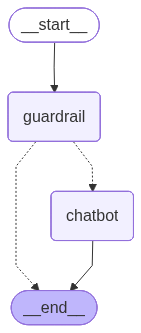

In [18]:
from IPython.display import Image, display

try: 
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

##### 1) 질문을 3자 이하로 테스트

In [19]:
graph.invoke({'messages': ['누구?']})

{'messages': ['누구?'], 'question_length': 3}

##### 2) 질문을 3자 초과 테스트

In [20]:
graph.invoke({'messages':["누구세요?"]})

content='안녕하세요! 저는 AI 언어 모델입니다. 여러분의 질문에 답하고, 다양한 주제에 대해 이야기할 수 있는 프로그램입니다. 도움이 필요하시면 언제든지 말씀해 주세요!' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 40, 'prompt_tokens': 11, 'total_tokens': 51, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_ab0b868503', 'id': 'chatcmpl-E1TlERLzYpzAQNqp4hRblPnJxwkCd', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019f5ff6-c33f-7b33-b0cd-51a9f3186d0a-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 11, 'output_tokens': 40, 'total_tokens': 51, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}


{'messages': ['누구세요?',
  '안녕하세요! 저는 AI 언어 모델입니다. 여러분의 질문에 답하고, 다양한 주제에 대해 이야기할 수 있는 프로그램입니다. 도움이 필요하시면 언제든지 말씀해 주세요!'],
 'question_length': 5}

### llm 이외의 도구를 불러오기

In [21]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)
tool.invoke({"query": "랭그래프가 무엇인가요?"})

{'query': '랭그래프가 무엇인가요?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/kr-ko/think/topics/langgraph',
   'title': 'LangGraph란 무엇인가요? | IBM',
   'content': 'LangChain에서 만든 LangGraph는 복잡한 생성형 AI 에이전트 워크플로를 구축, 배포, 관리하도록 설계된 오픈 소스 AI 에이전트 프레임워크입니다. LangGraph의 핵심은 그래프 기반 아키텍처의 힘을 사용하여 AI 에이전트 워크플로의 다양한 구성 요소 간의 복잡한 관계를 모델링하고 관리하는 것입니다. 다음 예제를 보면 LangGraph를 더 명확하게 이해할 수 있습니다. 이 그래프 기반 아키텍처를 강력하고 구성 가능한 "슈퍼 지도"라고 생각해 보세요. 사용자는 AI 워크플로가 이 "슈퍼 지도"의 "내비게이터"로 생각할 수 있습니다. 요약하자면, 그래프 기반 아키텍처("수퍼 지도") 속 최적의 경로는 AI 워크플로("Navigator")를 사용하여 차트로 작성하고 탐색합니다. 이 기술들을 API 및 툴 세트와 결합하여 사용자에게 챗봇, 상태 그래프, 기타 에이전트 기반 시스템을 포함한 AI 솔루션과 워크플로를 개발할 수 있는 다목적 플랫폼을 제공합니다. 이 프레임워크는 사용자가 복잡한 AI 워크플로를 만들고 관리할 수 있도록 함께 작동하는 여러 주요 구성 요소를 중심으로 구축되어 있습니다. 사용자는 API를 사용하여 LangGraph의 모든 상태 기반 그래프를 관리할 수 있습니다. 이 구성 요소들이 혁신적인 방식으로 결합되어 있어 사용자가 개별 구성 요소의 강점을 활용하는 정교한 AI 워크플로를 구축할 수 있습니다. **다중 에이전트 워크플로:** 복잡한 작업은 다중 에이전트 워크플로를 통해 처리할 수 있습니다.',
   'score': 0.8051581,
   'ra